In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [2]:
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

TensorFlow: 2.20.0
NumPy: 2.0.2
Pandas: 2.2.2


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/cryptosense/btcusd_1-min_data.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df.set_index('Timestamp', inplace=True)
df.head()

,Open,High,Low,Close,Volume
Timestamp,,,,,
2012-01-01 00:01:00,4.58,4.58,4.58,4.58,0.0
2012-01-01 00:02:00,4.58,4.58,4.58,4.58,0.0
2012-01-01 00:03:00,4.58,4.58,4.58,4.58,0.0
2012-01-01 00:04:00,4.58,4.58,4.58,4.58,0.0
2012-01-01 00:05:00,4.58,4.58,4.58,4.58,0.0


In [5]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nNulls:\n", df.isnull().sum())
df.describe()

Shape: (7613302, 5)

Dtypes:
 Open      float64
High      float64
Low       float64
Close     float64
Volume    float64
dtype: object

Nulls:
 Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


,Open,High,Low,Close,Volume
count,7.613302e+06,7.613302e+06,7.613302e+06,7.613302e+06,7.613302e+06
mean,2.340892e+04,2.341710e+04,2.340058e+04,2.340894e+04,4.995717e+00
std,3.130322e+04,3.131161e+04,3.129477e+04,3.130324e+04,2.166182e+01
min,3.800000e+00,3.800000e+00,3.800000e+00,3.800000e+00,0.000000e+00
25%,4.554500e+02,4.555900e+02,4.552600e+02,4.554500e+02,2.150706e-02
50%,7.977990e+03,7.983205e+03,7.972220e+03,7.977595e+03,4.493484e-01
75%,3.794125e+04,3.796007e+04,3.791985e+04,3.794178e+04,2.799942e+00
max,1.262020e+05,1.262720e+05,1.261580e+05,1.262020e+05,5.853852e+03


In [6]:
df_hourly = df.resample('1h').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
})

df_hourly.dropna(inplace=True)

print("Hourly shape:", df_hourly.shape)
df_hourly.head()

Hourly shape: (126889, 5)


,Open,High,Low,Close,Volume
Timestamp,,,,,
2012-01-01 00:00:00,4.58,4.58,4.58,4.58,0.000
2012-01-01 01:00:00,4.58,4.58,4.58,4.58,0.000
2012-01-01 02:00:00,4.58,4.58,4.58,4.58,0.000
2012-01-01 03:00:00,4.58,4.58,4.58,4.58,0.000
2012-01-01 04:00:00,4.58,4.58,4.58,4.58,1.502


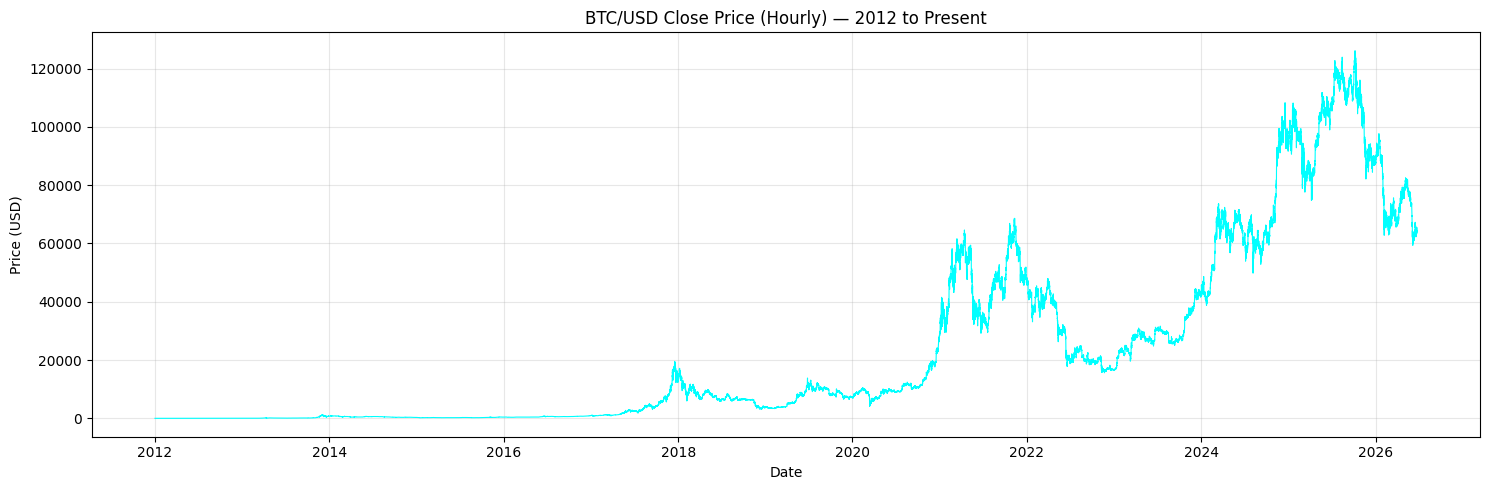

In [7]:
plt.figure(figsize=(15, 5))
plt.plot(df_hourly['Close'], color='cyan', linewidth=0.8)
plt.title('BTC/USD Close Price (Hourly) — 2012 to Present')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
close_prices = df_hourly[['Close']].values

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(close_prices)

print("Scaled shape:", scaled_data.shape)
print("Min:", scaled_data.min(), "Max:", scaled_data.max())

Scaled shape: (126889, 1)
Min: 0.0 Max: 0.9999999999999999


In [9]:
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

window_size = 60
X, y = create_sequences(scaled_data, window_size)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (126829, 60, 1)
y shape: (126829, 1)


In [10]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (101463, 60, 1) (101463, 1)
Test: (25366, 60, 1) (25366, 1)


In [11]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
2854/2854 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 1.6026e-04 - val_loss: 5.1659e-06
Epoch 2/50
2854/2854 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 1.4544e-04 - val_loss: 7.7645e-06
Epoch 3/50
2854/2854 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 1.4965e-04 - val_loss: 2.5523e-06
Epoch 4/50
2854/2854 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 1.4943e-04 - val_loss: 7.6584e-06
Epoch 5/50
2854/2854 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - loss: 1.4639e-04 - val_loss: 7.1538e-06
Epoch 6/50
2854/2854 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 1.4389e-04 - val_loss: 1.9207e-05
Epoch 7/50
2854/2854 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 1.4364e-04 - val_loss: 2.0527e-05
Epoch 8/50
2854/2854 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - loss: 1.4061e-04 - val_loss: 2.6426e-05


# Saving the trained model with scaler

In [14]:
import pickle

In [15]:
model.save('/content/drive/MyDrive/cryptosense/cryptosense_model.keras')

with open('/content/drive/MyDrive/cryptosense/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully")

Model and scaler saved successfully


# Load and Verify

In [16]:
from tensorflow.keras.models import load_model
import pickle

In [17]:
loaded_model = load_model('/content/drive/MyDrive/cryptosense/cryptosense_model.keras')

with open('/content/drive/MyDrive/cryptosense/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

sample_input = scaled_data[-60:].reshape(1, 60, 1)
predicted_scaled = loaded_model.predict(sample_input)

predicted_price = loaded_scaler.inverse_transform(predicted_scaled)
print("Predicted next hour BTC price: $", round(predicted_price[0][0], 2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
Predicted next hour BTC price: $ 62816.14


# Plot Predictions vs Actual

793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


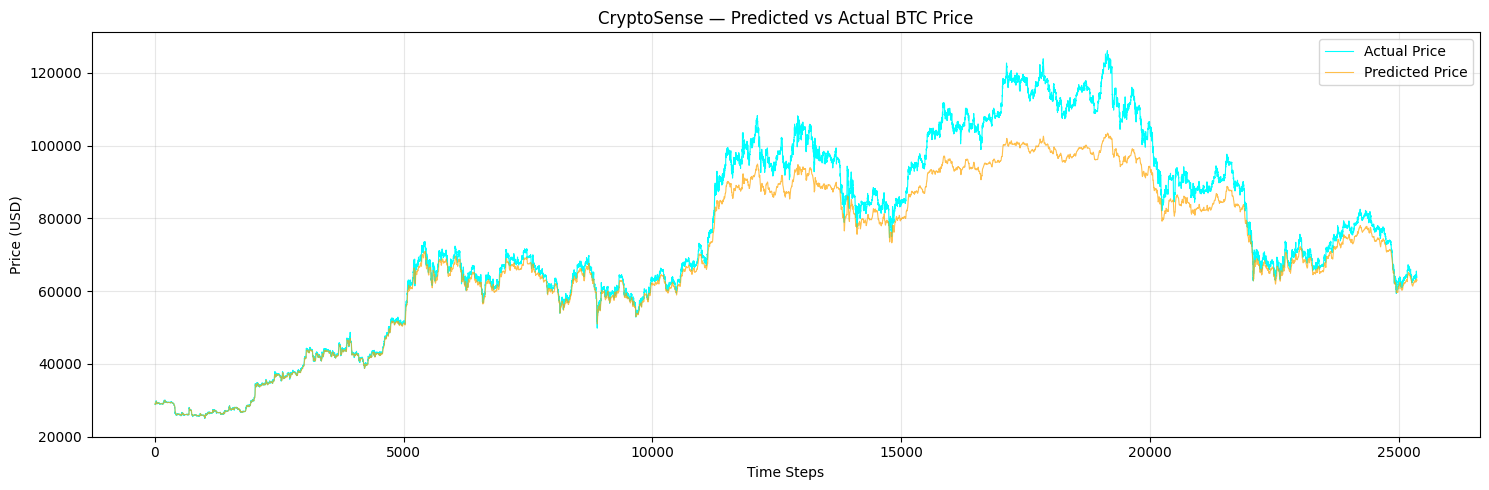

MSE: 51736864.43
MAE: $4908.52
RMSE: $7192.83


In [18]:
predictions_scaled = loaded_model.predict(X_test)
predictions = loaded_scaler.inverse_transform(predictions_scaled)
actual = loaded_scaler.inverse_transform(y_test)

# Plot
plt.figure(figsize=(15, 5))
plt.plot(actual, color='cyan', label='Actual Price', linewidth=0.8)
plt.plot(predictions, color='orange', label='Predicted Price', linewidth=0.8, alpha=0.7)
plt.title('CryptoSense — Predicted vs Actual BTC Price')
plt.xlabel('Time Steps')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Error metrics
mse = mean_squared_error(actual, predictions)
mae = mean_absolute_error(actual, predictions)
print(f"MSE: {mse:.2f}")
print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${mse**0.5:.2f}")

# Plot training loss to visualize learning

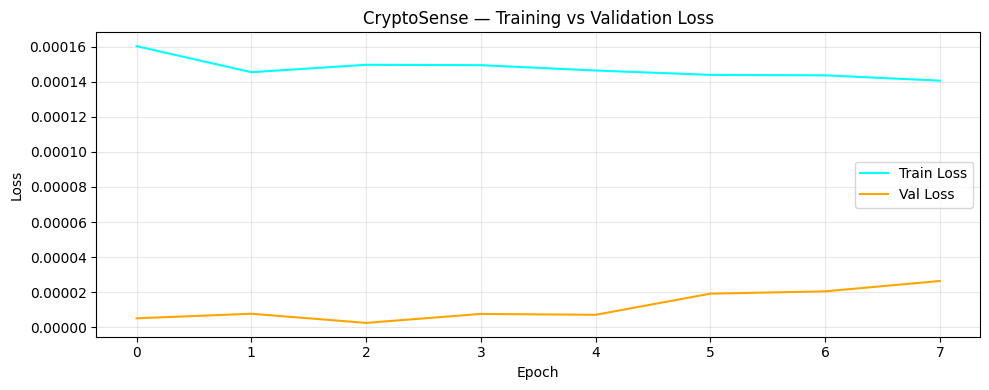

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss', color='cyan')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('CryptoSense — Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
!pip install fastapi uvicorn nest-asyncio pyngrok -q

# Code for main.py

In [26]:
import nest_asyncio
import uvicorn
from fastapi import FastAPI
from pydantic import BaseModel
import numpy as np
import pickle
from tensorflow.keras.models import load_model
from google.colab.output import eval_js

nest_asyncio.apply()

loaded_model = load_model('/content/drive/MyDrive/cryptosense/cryptosense_model.keras')
with open('/content/drive/MyDrive/cryptosense/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

app = FastAPI(title="CryptoSense API")

class PriceInput(BaseModel):
    prices: list[float]

@app.get("/")
def root():
    return {"message": "CryptoSense API is running"}

@app.post("/predict")
def predict(data: PriceInput):
    if len(data.prices) != 60:
        return {"error": "Exactly 60 price values required"}
    input_array = np.array(data.prices).reshape(-1, 1)
    scaled_input = loaded_scaler.transform(input_array)
    scaled_input = scaled_input.reshape(1, 60, 1)
    predicted_scaled = loaded_model.predict(scaled_input)
    predicted_price = loaded_scaler.inverse_transform(predicted_scaled)
    return {"predicted_next_hour_price": round(float(predicted_price[0][0]), 2)}

print("Public URL:", eval_js("google.colab.kernel.proxyPort(8000)"))

config = uvicorn.Config(app, host="0.0.0.0", port=8000, loop="asyncio")
server = uvicorn.Server(config)
await server.serve()

Public URL: https://8000-gpu-t4-s-kkb-usw1b1-3oetbncm12bc5-b.us-west1-1.prod.colab.dev


INFO:     Started server process [1114]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [1114]


JSONDecodeError: Expecting value: line 1 column 1 (char 0)